# Scratch

Quando inizi ricordati sempre di sistemare il kernel, è l'unica cosa da vedere prima di iniziare davvero a programmare.

In [39]:
# Sto importando per intero la libreria qiskit e i due nomi specifici dal pacchetto qiskit. 

from qiskit import QuantumCircuit, transpile

# transpile adatta un circuito atratto al set di gate e alla connettività che un backend specifco sa davvero eseguire.

## 1. Consideriamo diversi tipi di gate:

- Hadamard: $$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \qquad H|0\rangle = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}\begin{pmatrix}1\\0\end{pmatrix} = \frac{1}{\sqrt{2}} \begin{pmatrix}1\\1\end{pmatrix} =\frac{1}{\sqrt{2}} (|0\rangle + |1\rangle ) = |+\rangle , \qquad H|1\rangle = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}\begin{pmatrix}0\\1\end{pmatrix} = \frac{1}{\sqrt{2}} \begin{pmatrix}1\\-1\end{pmatrix} =\frac{1}{\sqrt{2}} (|0\rangle - |1\rangle ) = |-\rangle $$

In [40]:
qc = QuantumCircuit(1) # crea un circuito con un qubit

qc.h(0) # applica il gate Hadamard al qubit 0 (indice 0)

print(qc) # mostra qc come disegno testuale

   ┌───┐
q: ┤ H ├
   └───┘


Per misurare il quibit e leggere un risultato serve:
- un posto dove scrivere l'esito: un bit classico
- un posto che lo misuri: gate measure

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


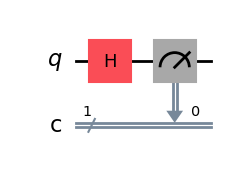

In [49]:
qc = QuantumCircuit(1, 1)

qc.h(0) # posiziono un gate al qubit 0 (indice 0)

qc.measure(0, 0) # misura il qubit 0, scrivi l'esito nel bit classico 0

print(qc)

qc.draw("mpl") # realizza un disegno più bello

## 2. Risultati 

Importo e creo il simulatore locale:
- AerSimulator è la classe del simulatore locale
- backend è l'oggetto istaanza che usiamo per eseguire il circuito

In [42]:
from qiskit_aer import AerSimulator
backend = AerSimulator()

Ora trasliamo il circuito per questo backend: prende il qc e lo riscrive nel linguaggio nativo di backend:

In [43]:
compiled = transpile(qc, backend)

Utilizziamo:
- job : è un oggetto, più uno "scontrino" del lavoro in corso che il risultato stesso
- job.result() aspetta che il job finisca e resistuisce un oggetto result (contenitore generico)
- .get_counts() estrae dal contenitore specificatamente le statstiche di una misura: un dizionario

In [44]:
job = backend.run(compiled, shots = 1024)

counts = job.result().get_counts() 

print(counts)

{'1': 516, '0': 508}


Visualizziamo ora i risultati con un istogramma

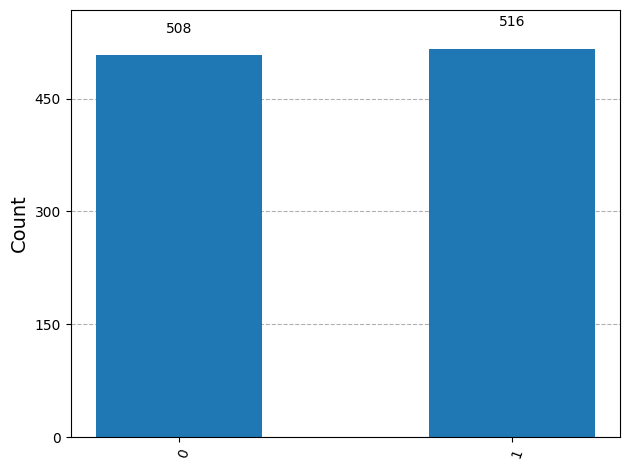

In [45]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)